# 🐾 Problem 2: Animals Sound Classification



In [34]:
import librosa
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

## Download the Dataset

We will be working with a portion of the [ESC-50: Dataset for Environmental Sound Classification](https://github.com/karolpiczak/ESC-50?tab=readme-ov-file), a well-labeled compilation of 2000 environmental audio clips designed for testing environmental sound classification techniques. This dataset features 5-second recordings, grouped into 50 semantic categories (each with 40 samples), which are broadly divided into five main groups: Animals, Natural soundscapes & water sounds, Human non-speech sounds, Interior/domestic sounds, and Exterior/urban noises.

In [35]:
# TODO: Mount your drive to gain access to the data


After unzipping your `data.zip` you should have the folder structure like this:
```
data/p2
├── annotations.csv
└── audio
    ├── 1-100032-A-0.wav
    ├── 1-103298-A-9.wav
    ...
```

In [36]:
import pandas as pd

df = pd.read_csv('data/p2/annotations.csv')
df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-103298-A-9.wav,1,9,crow,False,103298,A
2,1-110389-A-0.wav,1,0,dog,True,110389,A
3,1-121951-A-8.wav,1,8,sheep,False,121951,A
4,1-15689-A-4.wav,1,4,frog,False,15689,A


In [37]:
df['fold'].unique()

array([1, 2, 3, 4, 5])

In [38]:
df[['category', 'target']].drop_duplicates().sort_values(by='target')

,category,target
0,dog,0
26,rooster,1
18,pig,2
6,cow,3
4,frog,4
35,cat,5
9,hen,6
7,insects,7
3,sheep,8
1,crow,9


## Preprocessing

#### Understanding MFCC features

We will use the provided function `vis_mel_and_mfcc` to process sound input from a WAV file and generate two important representations: a Mel spectrogram and Mel-frequency cepstral coefficients (MFCCs). The Mel spectrogram captures the frequency content of the audio over time, while MFCCs provide a compact set of features commonly used in sound classification tasks. By learning to apply this function, students will gain hands-on experience in preprocessing audio data, a critical step in environmental sound classification and similar applications.

In [39]:
def vis_mel_and_mfcc(wav_file, n_mfcc=13):
    fig, ax = plt.subplots(nrows=2, sharex=True)
    y, sr = librosa.load(wav_file)

    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    img = librosa.display.specshow(librosa.power_to_db(mel, ref=np.max),
                                x_axis='time', y_axis='mel', ax=ax[0])
    fig.colorbar(img, ax=[ax[0]])
    ax[0].set(title='Mel spectrogram')
    ax[0].label_outer()

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc) # n_mfcc is the dimension of mfcc
    img = librosa.display.specshow(mfcc, x_axis='time', ax=ax[1])
    fig.colorbar(img, ax=[ax[1]])
    ax[1].set(title='MFCC')

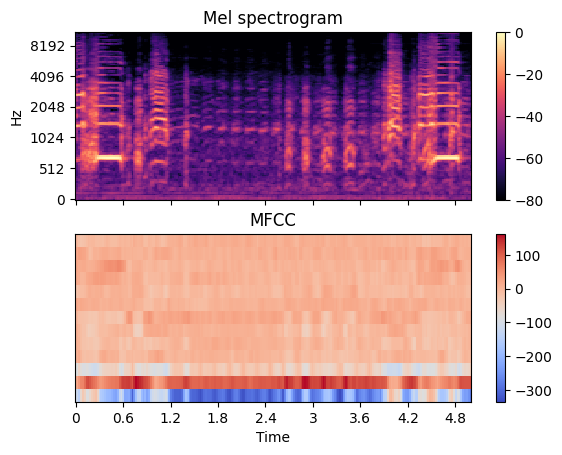

In [40]:
vis_mel_and_mfcc('data/p2/audio/1-5996-A-6.wav', 13)

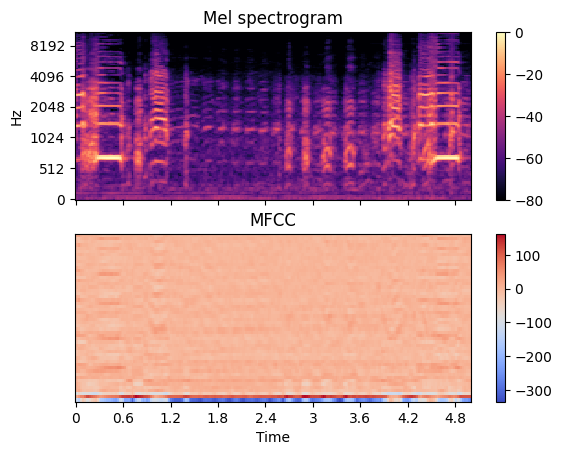

In [41]:
vis_mel_and_mfcc('data/p2/audio/1-5996-A-6.wav', 52)

#### Prepare the training data and testing data

In both the SVM and MLP experiments, we adopt 5-fold cross-validation to evaluate model performance. This means the dataset is split into 5 equally sized folds. In each round of evaluation, one fold is used as the validation (testing) set, while the remaining four are used for training. This process is repeated five times—each fold taking a turn as the validation set—ensuring a more reliable estimate of generalization performance.

In [42]:
# Define parameters
n_mfcc = 13  # Dimension of MFCC; matches the problem specification
hop_length = 100000 # Hop length for MFCC computation

# Initialize a dictionary to store data for each fold
fold_data = {fold: {'x': [], 'y': []} for fold in range(1, 6)}

# Process each fold (1 to 5)
for fold in range(1, 6):
    # Select all files for the current fold
    fold_df = df[df['fold'] == fold]

    for idx, row in fold_df.iterrows():
        wav_file = f"data/p2/audio/{row['filename']}"  # e.g., 'data/p2/audio/1-100032-A-0.wav'
        label = row['target']  # Target label for the sound (e.g., 0 for dog, 9 for crow)

        # Load audio and compute MFCCs
        data, sr = librosa.load(wav_file)
        # TODO: get the MFCC feature (remember to add in the hop_length argument to trim each audio into pieces)
        mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length)
        # TODO ENDS HERE
        mfcct = mfcc.T  # Transpose to get time frames as rows

        # Append MFCC features and labels for this fold
        for mfcc_feat in mfcct:
            fold_data[fold]['x'].append(mfcc_feat)
            fold_data[fold]['y'].append(label)

# Convert lists to numpy arrays for each fold
for fold in range(1, 6):
    fold_data[fold]['x'] = np.array(fold_data[fold]['x'])
    fold_data[fold]['y'] = np.array(fold_data[fold]['y'])
    print(f"Fold {fold} - x shape: {fold_data[fold]['x'].shape}, y shape: {fold_data[fold]['y'].shape}")

Fold 1 - x shape: (160, 13), y shape: (160,)
Fold 2 - x shape: (160, 13), y shape: (160,)
Fold 3 - x shape: (160, 13), y shape: (160,)
Fold 4 - x shape: (160, 13), y shape: (160,)
Fold 5 - x shape: (160, 13), y shape: (160,)


### 2-(a). [10pts] Follow the instructions in starter code and finish the implementations of SVM using scikit-learn. Report the5-fold cross-validation accuracy of different kernels (linear, poly, rbf) in your pdf.

In [43]:
# Define the kernels to evaluate
kernels = ['linear', 'poly', 'rbf']

# Store results for each kernel
results = {kernel: {'train_scores': [], 'val_scores': []} for kernel in kernels}

# Perform 5-fold cross-validation
for test_fold in range(1, 6):
    # Prepare training data by concatenating all folds except the test fold
    train_folds = [f for f in range(1, 6) if f != test_fold]
    train_x = np.concatenate([fold_data[f]['x'] for f in train_folds])
    train_y = np.concatenate([fold_data[f]['y'] for f in train_folds])

    # Use the test fold as validation data
    val_x = fold_data[test_fold]['x']
    val_y = fold_data[test_fold]['y']

    print(f"Fold {test_fold} - Training data: {train_x.shape} samples")
    print(f"Fold {test_fold} - Validation data: {val_x.shape} samples")

    # Evaluate each kernel
    for kernel in kernels:
        # TODO: Initialize and train the SVM classifier
        clf = make_pipeline(StandardScaler(), SVC(kernel=kernel))
        clf.fit(train_x, train_y)

        # TODO: Compute training and validation scores
        train_score = clf.score(train_x, train_y)
        val_score = clf.score(val_x, val_y)

        # Store the scores
        results[kernel]['train_scores'].append(train_score)
        results[kernel]['val_scores'].append(val_score)

        print(f"Fold {test_fold} - Kernel: {kernel}")
        print(f"Training accuracy: {train_score:.4f}")
        print(f"Validation accuracy: {val_score:.4f}")
        print()

Fold 1 - Training data: (640, 13) samples
Fold 1 - Validation data: (160, 13) samples
Fold 1 - Kernel: linear
Training accuracy: 0.5406
Validation accuracy: 0.3688

Fold 1 - Kernel: poly
Training accuracy: 0.6516
Validation accuracy: 0.3000

Fold 1 - Kernel: rbf
Training accuracy: 0.6953
Validation accuracy: 0.3500

Fold 2 - Training data: (640, 13) samples
Fold 2 - Validation data: (160, 13) samples
Fold 2 - Kernel: linear
Training accuracy: 0.5594
Validation accuracy: 0.3875

Fold 2 - Kernel: poly
Training accuracy: 0.6203
Validation accuracy: 0.3438

Fold 2 - Kernel: rbf
Training accuracy: 0.6859
Validation accuracy: 0.3937

Fold 3 - Training data: (640, 13) samples
Fold 3 - Validation data: (160, 13) samples
Fold 3 - Kernel: linear
Training accuracy: 0.5344
Validation accuracy: 0.4188

Fold 3 - Kernel: poly
Training accuracy: 0.6062
Validation accuracy: 0.4125

Fold 3 - Kernel: rbf
Training accuracy: 0.6859
Validation accuracy: 0.4437

Fold 4 - Training data: (640, 13) samples
Fold

In [44]:
# TODO: Calculate average n-fold accuracy for each kernel
print(f"{'Kernel':<10}{'Train Acc':>12}{'Val Acc':>12}")
for kernel in kernels:
    avg_train = np.mean(results[kernel]['train_scores'])
    avg_val = np.mean(results[kernel]['val_scores'])
    print(f"{kernel:<10}{avg_train:>12.4f}{avg_val:>12.4f}")


Kernel       Train Acc     Val Acc
linear          0.5413      0.3925
poly            0.6181      0.3425
rbf             0.6978      0.3987


### 2-(b). [10pts] Follow the instructions in starter code and finish the implementations of a single-layer MLP using scikit-learn. Report the 5-fold cross-validation accuracy of different hidden layer sizes (n=10, 100, 400) in your pdf.

In [45]:
# Define the hidden size
hidden_sizes = [10, 100, 400]

# Store results for each hidden size
results = {hidden_size: {'train_scores': [], 'val_scores': []} for hidden_size in hidden_sizes}

# Perform 5-fold cross-validation
for test_fold in range(1, 6):
    # Prepare training data by concatenating all folds except the test fold
    train_folds = [f for f in range(1, 6) if f != test_fold]
    train_x = np.concatenate([fold_data[f]['x'] for f in train_folds])
    train_y = np.concatenate([fold_data[f]['y'] for f in train_folds])

    # Use the test fold as validation data
    val_x = fold_data[test_fold]['x']
    val_y = fold_data[test_fold]['y']

    print(f"Fold {test_fold} - Training data: {train_x.shape} samples")
    print(f"Fold {test_fold} - Validation data: {val_x.shape} samples")

    # Evaluate each kernel
    for hidden_size in hidden_sizes:
        # TODO: Initialize and train the MLP classifier using "from sklearn.neural_network import MLPClassifier"
        clf = make_pipeline(
            StandardScaler(),
            MLPClassifier(hidden_layer_sizes=(hidden_size,), max_iter=300, random_state=0),
        )
        clf.fit(train_x, train_y)

        # TODO: Compute training and validation scores
        train_score = clf.score(train_x, train_y)
        val_score = clf.score(val_x, val_y)

        results[hidden_size]['train_scores'].append(train_score)
        results[hidden_size]['val_scores'].append(val_score)

        print(f"Fold {test_fold} - Hidden size: {hidden_size}")
        print(f"Training accuracy: {train_score:.4f}")
        print(f"Validation accuracy: {val_score:.4f}")
        print()


Fold 1 - Training data: (640, 13) samples
Fold 1 - Validation data: (160, 13) samples
Fold 1 - Hidden size: 10
Training accuracy: 0.4969
Validation accuracy: 0.3063



/Users/rishabhgoenka/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rishabhgoenka/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 1 - Hidden size: 100
Training accuracy: 0.7594
Validation accuracy: 0.3812



/Users/rishabhgoenka/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rishabhgoenka/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 1 - Hidden size: 400
Training accuracy: 0.9016
Validation accuracy: 0.3250

Fold 2 - Training data: (640, 13) samples
Fold 2 - Validation data: (160, 13) samples
Fold 2 - Hidden size: 10
Training accuracy: 0.5031
Validation accuracy: 0.3625



...

/Users/rishabhgoenka/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rishabhgoenka/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 4 - Hidden size: 400
Training accuracy: 0.8797
Validation accuracy: 0.3812

Fold 5 - Training data: (640, 13) samples
Fold 5 - Validation data: (160, 13) samples
Fold 5 - Hidden size: 10
Training accuracy: 0.4766
Validation accuracy: 0.3063



/Users/rishabhgoenka/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 5 - Hidden size: 100
Training accuracy: 0.7594
Validation accuracy: 0.4062

Fold 5 - Hidden size: 400
Training accuracy: 0.8828
Validation accuracy: 0.3750



/Users/rishabhgoenka/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [46]:
# TODO: Calculate average n-fold accuracy for each hidden size
print(f"{'Hidden':<10}{'Train Acc':>12}{'Val Acc':>12}")
for hidden_size in hidden_sizes:
    avg_train = np.mean(results[hidden_size]['train_scores'])
    avg_val = np.mean(results[hidden_size]['val_scores'])
    print(f"{hidden_size:<10}{avg_train:>12.4f}{avg_val:>12.4f}")


Hidden       Train Acc     Val Acc
10              0.4816      0.3400
100             0.7584      0.4000
400             0.8875      0.3763


### 2-(c). [10pt] In this part, you are encouraged to explore the dataset and models more deeply. You may choose one or more of the following directions, or propose your own:



1. Feature Analysis: Visualize the MFCC features (e.g., using PCA or t-SNE). Do you observe any clustering patterns across different classes?
2. Confusion Matrix: Plot a confusion matrix for your best-performing model. Which classes are most frequently confused? Why do you think that is the case?
3. Error Analysis: Select a few misclassified audio samples and inspect their waveforms, spectrograms, or MFCCs. What might be causing the model to fail?


In [47]:
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# From 2-(a) the best SVM kernel was rbf (mean val acc = 0.3987).
# From 2-(b) the best MLP hidden size was 100 (mean val acc = 0.4000).
# MLP(100) is our best-performing model, so we use it for the analysis below.

target_to_category = (
    df[['target', 'category']]
    .drop_duplicates()
    .sort_values('target')
    .set_index('target')['category']
    .to_dict()
)
class_labels = [target_to_category[t] for t in sorted(target_to_category)]

/Users/rishabhgoenka/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rishabhgoenka/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rishabhgoenka/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rishabhgoenka/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
 

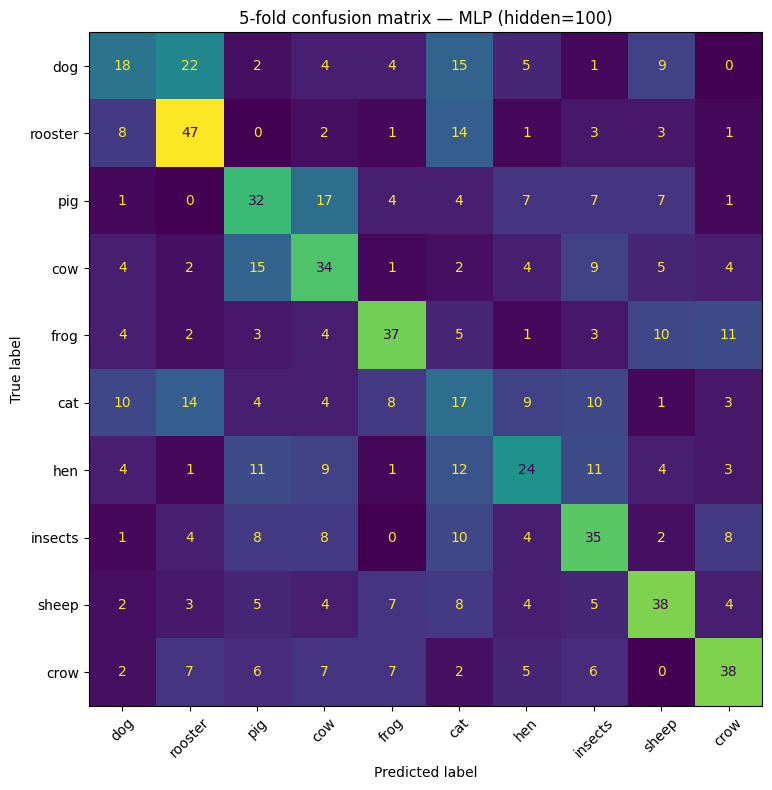

In [48]:
all_true, all_pred = [], []
for test_fold in range(1, 6):
    train_folds = [f for f in range(1, 6) if f != test_fold]
    train_x = np.concatenate([fold_data[f]['x'] for f in train_folds])
    train_y = np.concatenate([fold_data[f]['y'] for f in train_folds])
    val_x = fold_data[test_fold]['x']
    val_y = fold_data[test_fold]['y']

    clf = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=0),
    )
    clf.fit(train_x, train_y)
    all_true.append(val_y)
    all_pred.append(clf.predict(val_x))

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)

cm = confusion_matrix(y_true, y_pred, labels=sorted(target_to_category))
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(
    ax=ax, xticks_rotation=45, colorbar=False
)
ax.set_title("5-fold confusion matrix — MLP (hidden=100)")
plt.tight_layout()
plt.show()

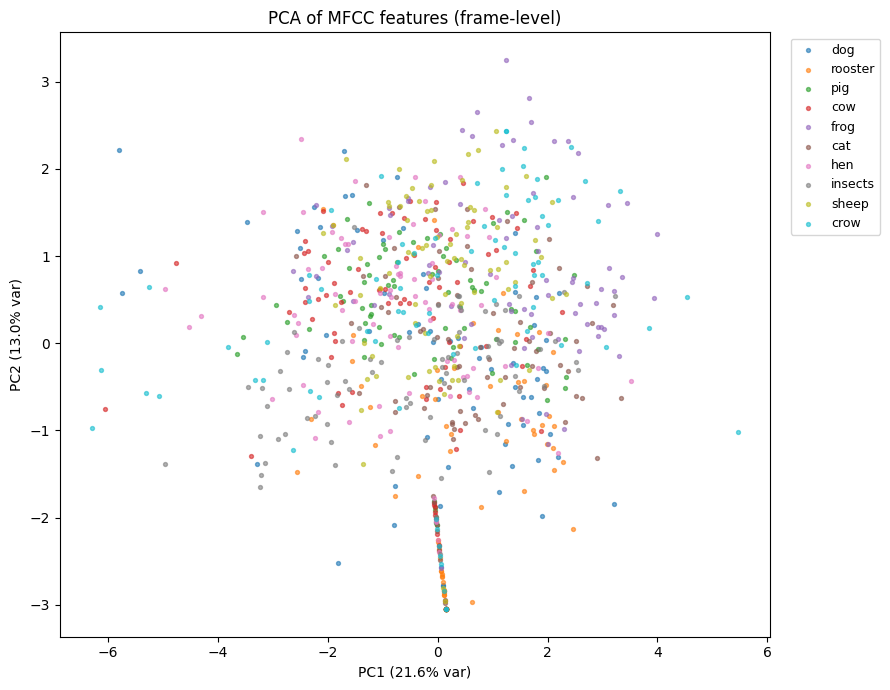

In [49]:
all_x = np.concatenate([fold_data[f]['x'] for f in range(1, 6)])
all_y = np.concatenate([fold_data[f]['y'] for f in range(1, 6)])

scaler = StandardScaler().fit(all_x)
pca = PCA(n_components=2, random_state=0)
proj = pca.fit_transform(scaler.transform(all_x))

fig, ax = plt.subplots(figsize=(9, 7))
cmap = plt.get_cmap('tab10')
for t in sorted(target_to_category):
    mask = all_y == t
    ax.scatter(proj[mask, 0], proj[mask, 1], s=8, alpha=0.6,
               color=cmap(t % 10), label=target_to_category[t])
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA of MFCC features (frame-level)")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()